# **DIVA OCTAVIANI - 2311102006**

Pada tugas ini, dilakukan text processing terhadap dataset hasil scraping komentar YouTube terkait kasus korupsi di Pekalongan. Tujuannya adalah untuk menghasilkan kata-kata bermakna yang dapat merepresentasikan kondisi dan opini publik terhadap kasus tersebut.

Proses yang dilakukan meliputi:

1. Load Dataset
2. Hapus Data Duplikat
3. Data Cleaning
4. WordCloud Sebelum Text Processing
5. Case Folding
6. Normalization
7. Tokenization
8. Filtering
9. Stopword Removal
10. Stemming
11. WordCloud Setelah Text Processing

### **Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/NLP/T2 Data Acquisition/Dataset Hasil Scraping/scraping_youtube.xlsx'

df = pd.read_excel(file_path)

print(df.shape)
print(df.columns.tolist())
df.head()

(1233, 5)
['Unnamed: 0', 'username', 'komentar', 'likes', 'waktu']


,Unnamed: 0,username,komentar,likes,waktu
0,0,@KholiqManggala,Segera sahkan UU untuk memiskinkan koruptor,86,6 hari yang lalu
1,1,@luskaproject4120,saya kira semua bupati di indonesia punya skem...,136,6 hari yang lalu
2,2,@denyadhitiya,Tidak ada hukuman koruptor selain mati,94,6 hari yang lalu
3,3,@WaIdi-f2p,Sudah hal lumrah di negri ini 95 persen pejaba...,31,6 hari yang lalu
4,4,@vidisutaman4330,Kapaan ya koruptor dihukum mati??,76,6 hari yang lalu


In [ ]:
# Hapus kolom Unnamed
df.drop(columns=['Unnamed: 0'], inplace=True)

# Cek missing values
print(df.isnull().sum())
print(f"\nTotal komentar: {len(df)}")
df.head()

username    0
komentar    0
likes       0
waktu       0
dtype: int64

Total komentar: 1233


,username,komentar,likes,waktu
0,@KholiqManggala,Segera sahkan UU untuk memiskinkan koruptor,86,6 hari yang lalu
1,@luskaproject4120,saya kira semua bupati di indonesia punya skem...,136,6 hari yang lalu
2,@denyadhitiya,Tidak ada hukuman koruptor selain mati,94,6 hari yang lalu
3,@WaIdi-f2p,Sudah hal lumrah di negri ini 95 persen pejaba...,31,6 hari yang lalu
4,@vidisutaman4330,Kapaan ya koruptor dihukum mati??,76,6 hari yang lalu


### **Hapus Data Duplikat**

In [ ]:
# Lihat data duplikat
duplikat = df[df.duplicated(subset='komentar', keep=False)]
duplikat_sorted = duplikat.sort_values('komentar')

print(f"Jumlah baris duplikat: {len(duplikat_sorted)}")
duplikat_sorted

Jumlah baris duplikat: 19


,username,komentar,likes,waktu
70,@budimathematic2231,Betul,1,6 hari yang lalu
635,@DeveloperOtodidaks,Betul,0,7 hari yang lalu
389,@iriantoanto2658,Hukum mati,0,5 hari yang lalu
859,@linalukitasari3661,Hukum mati,0,4 hari yang lalu
189,@lepots91,Kenyang banget tuh ibuk mimpin di daerah terpe...,0,6 hari yang lalu
276,@lepots91,Kenyang banget tuh ibuk mimpin di daerah terpe...,0,6 hari yang lalu
1106,@Sutrisno-c6e,Pejabat kerjone mung maling uang rakyat.lewat ...,0,7 hari yang lalu
1011,@Sutrisno-c6e,Pejabat kerjone mung maling uang rakyat.lewat ...,0,7 hari yang lalu
934,@Sutrisno-c6e,"Terusno yen dadi maling bu, mengko keno karmane.",0,7 hari yang lalu
1074,@Sutrisno-c6e,"Terusno yen dadi maling bu, mengko keno karmane.",0,7 hari yang lalu


In [ ]:
# Hapus duplikat
df.drop_duplicates(subset='komentar', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Jumlah komentar setelah hapus duplikat: {len(df)}")

Jumlah komentar setelah hapus duplikat: 1222


### **Data Cleaning**

In [ ]:
import re
import string

# Fungsi hapus emoji
def remove_emoji(text):
    if text is not None and isinstance(text, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"
            u"\U0001F300-\U0001F5FF"
            u"\U0001F680-\U0001F6FF"
            u"\U0001F700-\U0001F77F"
            u"\U0001F780-\U0001F7FF"
            u"\U0001F800-\U0001F8FF"
            u"\U0001F900-\U0001F9FF"
            u"\U0001FA00-\U0001FA6F"
            u"\U0001FA70-\U0001FAFF"
            u"\U0001F004-\U0001F0CF"
            u"\U0001F1E0-\U0001F1FF"
            "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', text)
    else:
        return text

# Fungsi hapus simbol
def remove_symbols(text):
    if text is not None and isinstance(text, str):
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        return text
    else:
        return text

# Fungsi hapus angka
def remove_numbers(text):
    if text is not None and isinstance(text, str):
        text = re.sub(r'\d', '', text)
        return text
    else:
        return text

# Fungsi hapus mention & URL
def remove_username(text):
    if text is not None and isinstance(text, str):
        text = re.sub(r'@\S+', '', text)
        text = re.sub(r'http\S+|www\S+', '', text)
        return text
    else:
        return text

# Terapkan cleaning
df['cleaning'] = df['komentar'].apply(lambda x: remove_username(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))

df[['komentar', 'cleaning']].head(10)

,komentar,cleaning
0,Segera sahkan UU untuk memiskinkan koruptor,Segera sahkan UU untuk memiskinkan koruptor
1,saya kira semua bupati di indonesia punya skem...,saya kira semua bupati di indonesia punya skem...
2,Tidak ada hukuman koruptor selain mati,Tidak ada hukuman koruptor selain mati
3,Sudah hal lumrah di negri ini 95 persen pejaba...,Sudah hal lumrah di negri ini persen pejabat ...
4,Kapaan ya koruptor dihukum mati??,Kapaan ya koruptor dihukum mati
5,Sangking bloon nya warga Pekalongan kaya gitu ...,Sangking bloon nya warga Pekalongan kaya gitu ...
6,Emang aslinya semua bupati dan pejabat emang k...,Emang aslinya semua bupati dan pejabat emang k...
7,Sebenernya klo mo jujur kesalahan Ada pada pem...,Sebenernya klo mo jujur kesalahan Ada pada pem...
8,Niatnya jelas jadi pemimpin emang bukan mau me...,Niatnya jelas jadi pemimpin emang bukan mau me...
9,"Indonesia kaya bumixa,kalo tidak di korupsi, I...",Indonesia kaya bumixakalo tidak di korupsi Ind...


In [ ]:
# Cek yang jadi kosong setelah cleaning
df['cleaning'] = df['cleaning'].str.strip()
kosong = df[df['cleaning'] == '']
print(f"Jumlah komentar kosong setelah cleaning: {len(kosong)}")

Jumlah komentar kosong setelah cleaning: 9


In [ ]:
# Hapus yang kosong setelah cleaning
df = df[df['cleaning'] != '']
df.reset_index(drop=True, inplace=True)

print(f"Total komentar setelah hapus kosong: {len(df)}")

Total komentar setelah hapus kosong: 1213


### **WordCloud Sebelum Text Processing**

In [ ]:
!pip install wordcloud

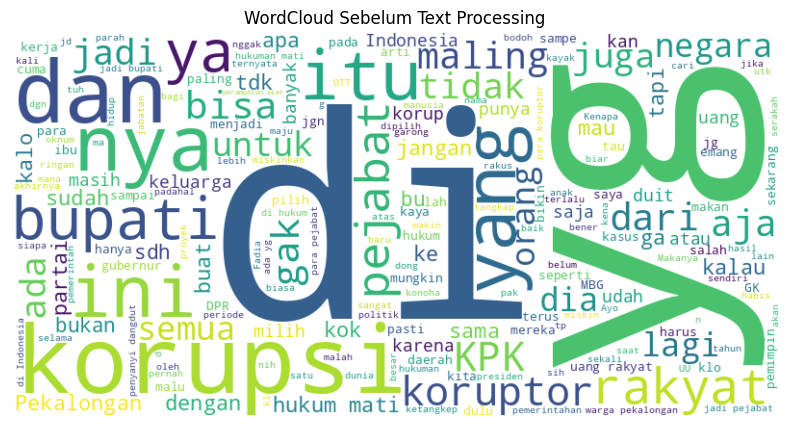

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# WordCloud
all_text = ' '.join(df['komentar'])
wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Sebelum Text Processing')
plt.show()

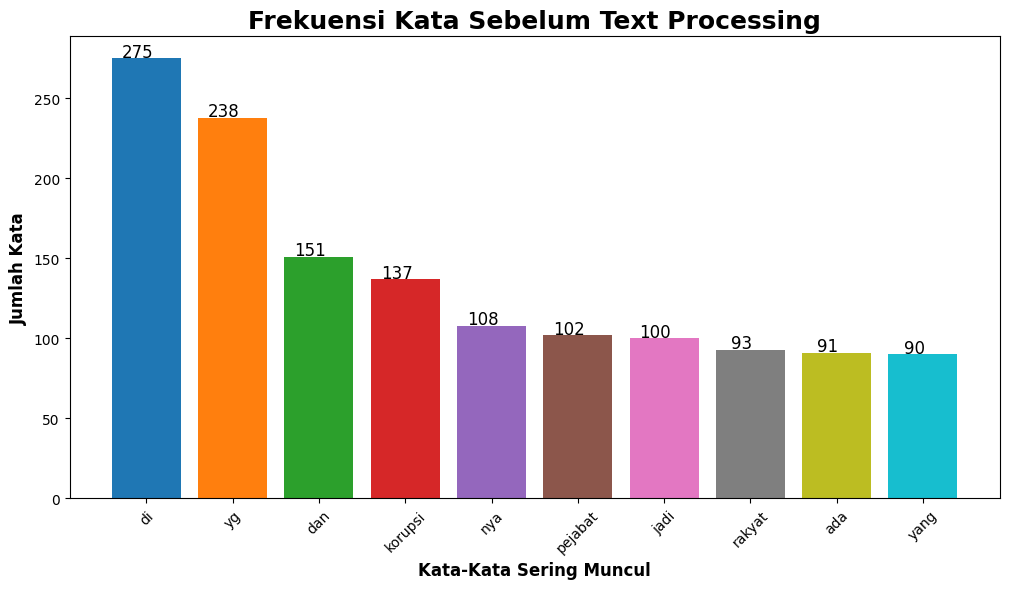

In [ ]:
# Frekuensi Kata
all_words = all_text.split()
word_counts = Counter(all_words)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata Sebelum Text Processing", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1,
             str(num), fontsize=12, color='black', ha='center')

plt.show()

WordCloud dan grafik frekuensi kata di atas menggambarkan kemunculan kata dari 1213 komentar sebelum *Text Processing*. Kata tidak bermakna seperti "di", "yg", dan "dan" masih mendominasi, sehingga *Text Processing* diperlukan agar kata-kata tersebut dapat dihilangkan.

# **Text Processing**

### **Case Folding**

In [ ]:
df['case_folding'] = df['cleaning'].str.lower()

df[['komentar', 'case_folding']].head(10)

,komentar,case_folding
0,Segera sahkan UU untuk memiskinkan koruptor,segera sahkan uu untuk memiskinkan koruptor
1,saya kira semua bupati di indonesia punya skem...,saya kira semua bupati di indonesia punya skem...
2,Tidak ada hukuman koruptor selain mati,tidak ada hukuman koruptor selain mati
3,Sudah hal lumrah di negri ini 95 persen pejaba...,sudah hal lumrah di negri ini persen pejabat ...
4,Kapaan ya koruptor dihukum mati??,kapaan ya koruptor dihukum mati
5,Sangking bloon nya warga Pekalongan kaya gitu ...,sangking bloon nya warga pekalongan kaya gitu ...
6,Emang aslinya semua bupati dan pejabat emang k...,emang aslinya semua bupati dan pejabat emang k...
7,Sebenernya klo mo jujur kesalahan Ada pada pem...,sebenernya klo mo jujur kesalahan ada pada pem...
8,Niatnya jelas jadi pemimpin emang bukan mau me...,niatnya jelas jadi pemimpin emang bukan mau me...
9,"Indonesia kaya bumixa,kalo tidak di korupsi, I...",indonesia kaya bumixakalo tidak di korupsi ind...


### **Normalization** (mengubah kata tidak baku menjadi baku)

In [ ]:
import pandas as pd
import requests
from io import BytesIO

def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []
        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
                else:
                    replaced_words.append(word)
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ' '
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []
    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

In [ ]:
# Unduh dan baca kamus dari GitHub
url = "https://github.com/analysisdatasentiment/kamus_kata_baku/raw/main/kamuskatabaku.xlsx"
response = requests.get(url)
file_excel = BytesIO(response.content)
kamus_data = pd.read_excel(file_excel)

kamus_tidak_baku_dict = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))
kamus_tidak_baku_dict['apk'] = 'aplikasi'

print(f"Jumlah kamus: {len(kamus_tidak_baku_dict)} kata")

Jumlah kamus: 4348 kata


In [ ]:
df[['normalisasi', 'Kata_Baku', 'Kata_Tidak_Baku', 'Kata_Tidak_Baku_Hash']] = df['case_folding'].apply(
    lambda x: pd.Series(replace_taboo_words(x, kamus_tidak_baku_dict))
)

df[['komentar', 'case_folding', 'normalisasi']].head(10)

,komentar,case_folding,normalisasi
0,Segera sahkan UU untuk memiskinkan koruptor,segera sahkan uu untuk memiskinkan koruptor,segera sahkan uu untuk memiskinkan koruptor
1,saya kira semua bupati di indonesia punya skem...,saya kira semua bupati di indonesia punya skem...,saya kira semua bupati di indonesia punya skem...
2,Tidak ada hukuman koruptor selain mati,tidak ada hukuman koruptor selain mati,tidak ada hukuman koruptor selain mati
3,Sudah hal lumrah di negri ini 95 persen pejaba...,sudah hal lumrah di negri ini persen pejabat ...,sudah hal lumrah di negeri ini persen pejabat ...
4,Kapaan ya koruptor dihukum mati??,kapaan ya koruptor dihukum mati,kapan ya koruptor dihukum mati
5,Sangking bloon nya warga Pekalongan kaya gitu ...,sangking bloon nya warga pekalongan kaya gitu ...,sangking bloon ya warga pekalongan kayak begit...
6,Emang aslinya semua bupati dan pejabat emang k...,emang aslinya semua bupati dan pejabat emang k...,memang aslinya semua bupati dan pejabat memang...
7,Sebenernya klo mo jujur kesalahan Ada pada pem...,sebenernya klo mo jujur kesalahan ada pada pem...,sebenarnya kalau mau jujur kesalahan ada pada ...
8,Niatnya jelas jadi pemimpin emang bukan mau me...,niatnya jelas jadi pemimpin emang bukan mau me...,niatnya jelas jadi pemimpin memang bukan mau m...
9,"Indonesia kaya bumixa,kalo tidak di korupsi, I...",indonesia kaya bumixakalo tidak di korupsi ind...,indonesia kayak bumixakalo tidak di korupsi in...


### **Tokenization**

In [ ]:
import nltk
nltk.download('all')

df['tokenization'] = df['normalisasi'].apply(nltk.word_tokenize)

df[['normalisasi', 'tokenization']].head(10)

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

,normalisasi,tokenization
0,segera sahkan uu untuk memiskinkan koruptor,"[segera, sahkan, uu, untuk, memiskinkan, korup..."
1,saya kira semua bupati di indonesia punya skem...,"[saya, kira, semua, bupati, di, indonesia, pun..."
2,tidak ada hukuman koruptor selain mati,"[tidak, ada, hukuman, koruptor, selain, mati]"
3,sudah hal lumrah di negeri ini persen pejabat ...,"[sudah, hal, lumrah, di, negeri, ini, persen, ..."
4,kapan ya koruptor dihukum mati,"[kapan, ya, koruptor, dihukum, mati]"
5,sangking bloon ya warga pekalongan kayak begit...,"[sangking, bloon, ya, warga, pekalongan, kayak..."
6,memang aslinya semua bupati dan pejabat memang...,"[memang, aslinya, semua, bupati, dan, pejabat,..."
7,sebenarnya kalau mau jujur kesalahan ada pada ...,"[sebenarnya, kalau, mau, jujur, kesalahan, ada..."
8,niatnya jelas jadi pemimpin memang bukan mau m...,"[niatnya, jelas, jadi, pemimpin, memang, bukan..."
9,indonesia kayak bumixakalo tidak di korupsi in...,"[indonesia, kayak, bumixakalo, tidak, di, koru..."


### **Filtering**

In [ ]:
import string

def filtering(text):
    text = text.translate(str.maketrans('', '', string.punctuation))
    return nltk.word_tokenize(text)

df['filtering'] = df['normalisasi'].apply(filtering)

all_tokens = [token for tokens in df['filtering'] for token in tokens]
kemunculan = nltk.FreqDist(all_tokens)
print(kemunculan.most_common(20))

df[['tokenization', 'filtering']].head(10)

[('yang', 401), ('tidak', 347), ('di', 334), ('ya', 276), ('korupsi', 209), ('dan', 175), ('jadi', 163), ('sudah', 150), ('pejabat', 148), ('bupati', 147), ('rakyat', 143), ('ini', 136), ('kalau', 134), ('saja', 121), ('itu', 110), ('ada', 109), ('koruptor', 102), ('maling', 98), ('dari', 92), ('juga', 91)]


,tokenization,filtering
0,"[segera, sahkan, uu, untuk, memiskinkan, korup...","[segera, sahkan, uu, untuk, memiskinkan, korup..."
1,"[saya, kira, semua, bupati, di, indonesia, pun...","[saya, kira, semua, bupati, di, indonesia, pun..."
2,"[tidak, ada, hukuman, koruptor, selain, mati]","[tidak, ada, hukuman, koruptor, selain, mati]"
3,"[sudah, hal, lumrah, di, negeri, ini, persen, ...","[sudah, hal, lumrah, di, negeri, ini, persen, ..."
4,"[kapan, ya, koruptor, dihukum, mati]","[kapan, ya, koruptor, dihukum, mati]"
5,"[sangking, bloon, ya, warga, pekalongan, kayak...","[sangking, bloon, ya, warga, pekalongan, kayak..."
6,"[memang, aslinya, semua, bupati, dan, pejabat,...","[memang, aslinya, semua, bupati, dan, pejabat,..."
7,"[sebenarnya, kalau, mau, jujur, kesalahan, ada...","[sebenarnya, kalau, mau, jujur, kesalahan, ada..."
8,"[niatnya, jelas, jadi, pemimpin, memang, bukan...","[niatnya, jelas, jadi, pemimpin, memang, bukan..."
9,"[indonesia, kayak, bumixakalo, tidak, di, koru...","[indonesia, kayak, bumixakalo, tidak, di, koru..."


### **Stopword Removal**

In [ ]:
from nltk.corpus import stopwords

nltk.download('stopwords')

custom_stopword = {'ya', 'yaa', 'nya', 'uu', 'kayak', 'gini', 'aja'}

listStopword = set(stopwords.words('indonesian'))
listStopword.update(custom_stopword)

def stopword_removal(tokens):
    removed = []
    for t in tokens:
        if t not in listStopword:
            removed.append(t)
    return removed

df['stopword_removal'] = df['filtering'].apply(stopword_removal)

df[['filtering', 'stopword_removal']].head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,filtering,stopword_removal
0,"[segera, sahkan, uu, untuk, memiskinkan, korup...","[sahkan, memiskinkan, koruptor]"
1,"[saya, kira, semua, bupati, di, indonesia, pun...","[bupati, indonesia, skema, korupsi]"
2,"[tidak, ada, hukuman, koruptor, selain, mati]","[hukuman, koruptor, mati]"
3,"[sudah, hal, lumrah, di, negeri, ini, persen, ...","[lumrah, negeri, persen, pejabat, korup, buday..."
4,"[kapan, ya, koruptor, dihukum, mati]","[koruptor, dihukum, mati]"
5,"[sangking, bloon, ya, warga, pekalongan, kayak...","[sangking, bloon, warga, pekalongan, kali, dip..."
6,"[memang, aslinya, semua, bupati, dan, pejabat,...","[aslinya, bupati, pejabat, bedanya, sembunyika..."
7,"[sebenarnya, kalau, mau, jujur, kesalahan, ada...","[jujur, kesalahan, pemilihan, pemimpin, kepala..."
8,"[niatnya, jelas, jadi, pemimpin, memang, bukan...","[niatnya, pemimpin, memajukan, mensejahterakan..."
9,"[indonesia, kayak, bumixakalo, tidak, di, koru...","[indonesia, bumixakalo, korupsi, indonesia, ne..."


### **Stemming**

In [ ]:
!pip install PySastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['stemming'] = df['stopword_removal'].apply(stemming)

df[['stopword_removal', 'stemming']].head(10)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 10.0 MB/s eta 0:00:00


,stopword_removal,stemming
0,"[sahkan, memiskinkan, koruptor]","[sahkan, miskin, koruptor]"
1,"[bupati, indonesia, skema, korupsi]","[bupati, indonesia, skema, korupsi]"
2,"[hukuman, koruptor, mati]","[hukum, koruptor, mati]"
3,"[lumrah, negeri, persen, pejabat, korup, buday...","[lumrah, negeri, persen, jabat, korup, budaya,..."
4,"[koruptor, dihukum, mati]","[koruptor, hukum, mati]"
5,"[sangking, bloon, warga, pekalongan, kali, dip...","[sangking, bloon, warga, kalong, kali, pilih]"
6,"[aslinya, bupati, pejabat, bedanya, sembunyika...","[asli, bupati, jabat, beda, sembunyi, expose, ..."
7,"[jujur, kesalahan, pemilihan, pemimpin, kepala...","[jujur, salah, pilih, pimpin, kepala, desa, bu..."
8,"[niatnya, pemimpin, memajukan, mensejahterakan...","[niat, pimpin, maju, sejahtera, daerah, pimpin..."
9,"[indonesia, bumixakalo, korupsi, indonesia, ne...","[indonesia, bumixakalo, korupsi, indonesia, ne..."


### **WordCloud Setelah Text Processing**

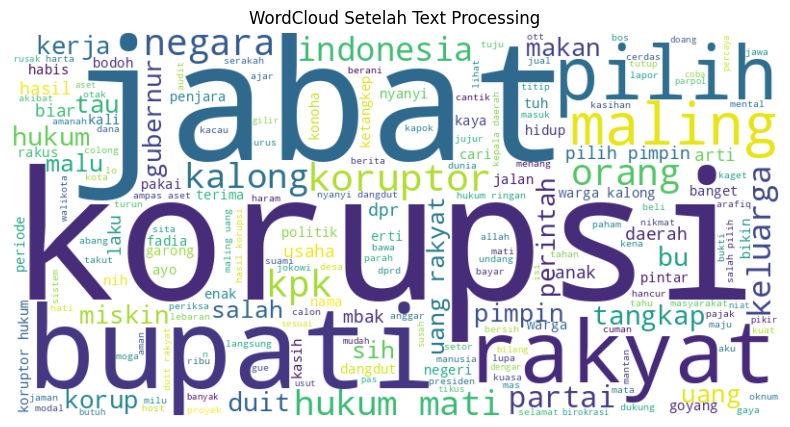

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Gabungkan semua token hasil stemming
all_text = ' '.join([word for tokens in df['stemming'] for word in tokens])

# WordCloud
wc = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Setelah Text Processing')
plt.show()

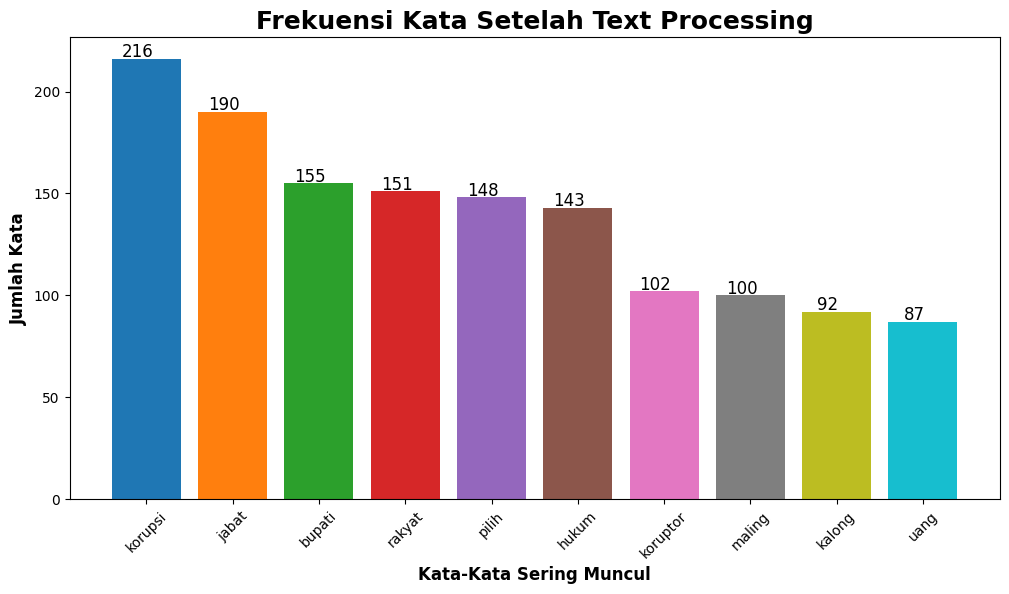

In [ ]:
# Frekuensi Kata Setelah Text Processing
all_words = all_text.split()
word_counts = Counter(all_words)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata Setelah Text Processing", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1,
             str(num), fontsize=12, color='black', ha='center')

plt.show()

Berdasarkan hasil text processing terhadap komentar YouTube seputar kasus korupsi di Pekalongan, sebelumnya kata tidak bermakna seperti "di", "yg", dan "dan" masih mendominasi. Setelah melalui proses case folding, normalisasi, tokenization, filtering, stopword removal, dan stemming, kata bermakna lebih terlihat jelas dengan "korupsi", "jabat", "bupati", "rakyat", dan "hukum" sebagai kata paling dominan, mencerminkan kekecewaan publik terhadap tindakan korupsi pejabat daerah serta tuntutan hukuman tegas bagi para koruptor.

Namun, ditemukan bahwa proses stemming menggunakan Sastrawi memiliki keterbatasan dalam mengenali nama tempat, seperti kata "pekalongan" yang terstem menjadi "kalong" karena awalan pe- dan akhiran -an dianggap sebagai imbuhan. Hal ini menjadi catatan penting bahwa preprocessing pada data yang mengandung nama tempat atau nama orang perlu penanganan khusus agar tidak menghasilkan kata yang tidak relevan.